In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/customer_booking.csv', encoding= 'ISO-8859-1')
df.sample(5)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
44451,3,Mobile,RoundTrip,79,6,11,Tue,DMKHND,Thailand,1,0,1,7.57,0
43826,2,Internet,RoundTrip,22,6,8,Wed,CTSDMK,Thailand,1,0,0,8.67,0
3909,1,Internet,RoundTrip,99,20,14,Mon,CGKICN,South Korea,1,0,1,6.62,0
13604,1,Internet,RoundTrip,14,45,11,Mon,ICNKNO,Indonesia,1,0,0,6.62,1
123,1,Internet,RoundTrip,71,29,10,Fri,AKLKUL,New Zealand,1,0,0,8.83,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


In [4]:
list(df['flight_day'].unique())

['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri']

In [5]:
day2num = {
    'Mon': 1, 
    'Tue': 2,
    'Wed': 3,
    'Thu': 4,
    'Fri': 5,
    'Sat': 6,
    'Sun': 7, 
}

df['flight_day'] = df['flight_day'].map(day2num)

In [6]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [7]:
# Split features and target
X = df.drop("booking_complete", axis=1)
y = df["booking_complete"]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Identify categorical columns
str_cols = X.select_dtypes(include="str").columns

# Build preprocessing (encoding ONLY here)
preprocessor = ColumnTransformer(
    transformers=[
        ("str", OneHotEncoder(handle_unknown="ignore"), str_cols)
    ],
    remainder="passthrough"
)


In [ ]:
# Create full ML pipeline
model = RandomForestClassifier(random_state=42)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# Train model
clf.fit(X_train, y_train)

In [ ]:
# Predict
y_pred = clf.predict(X_test)

# Evaluate
accuracy_score(y_test, y_pred)

0.8535

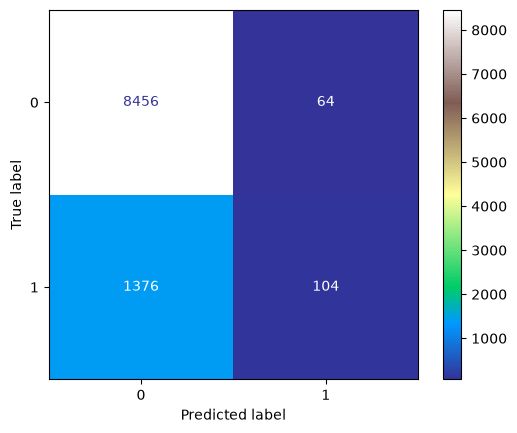

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot(cmap='terrain')

plt.show()

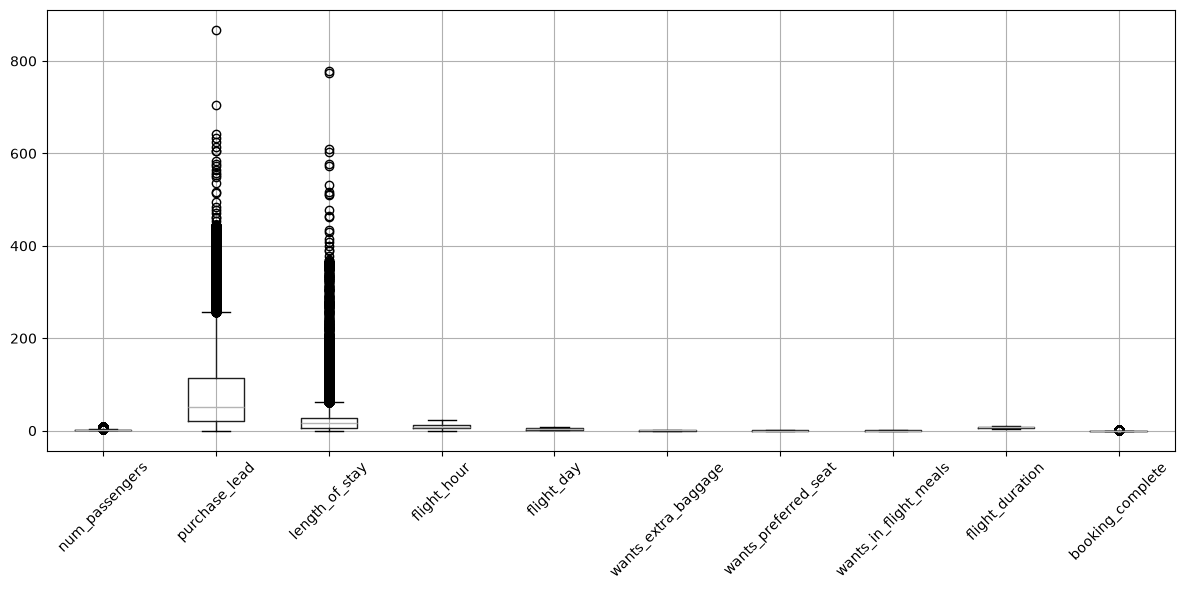

In [ ]:
# Now I would try with XGBOOST -> It's a little sensitive to outliers. So first, I am going to work on them.
plt.figure(figsize=(12,6))
df.boxplot(rot=45)
plt.tight_layout() 
plt.show()

In [ ]:
# Winsorisation of the Outliers, in order not to delete any data
numeric_cols = X.select_dtypes(include="int64").columns

for col in numeric_cols:
    upper = df[col].quantile(0.99)
    lower = df[col].quantile(0.01)

    df[col] = df[col].clip(lower, upper)

In [ ]:
# Define the Model and the pipeline
model2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

clf2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model2)
])

In [ ]:
# Train
clf2.fit(X_train, y_train)
# Predict
y_pred = clf2.predict(X_test)
# Evaluate
accuracy_score(y_test, y_pred)

0.8559

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=clf2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf2.classes_)
disp.plot(cmap='PuRd')

plt.show()